## Rainfall Pattern Classification to Optimize Storage and Usage Strategies

In [1]:
import os 
import random 
import shutil 

**Dataset**

The dataset consists of rainfall images of various patterns such as: 
- heavy rainfall (extremely hazy, water logging, low visibility)
- medium rainfall (little hazy, close to no water logging)
- light rainfall (no haziness, clear sky, complete visibility)

We have rainfall images 748 images in training directory and 73 images for validation 

- The dataset is organized in 'dataset' folder with train and val sets
- Following pre-processing has been done before hand in data for better results 
  - Auto-adjusted contrast using Histogram Equalization
  - Shear, Exposure and Zoom adjustments

**Let's create Validation Dataset**

Since, we only have train dataset, we will create validation set with 10% val data 

In [5]:
def create_validation_dataset(dataset_path, valid_path, percentage=0.1):
    if not os.path.exists(valid_path):
        os.makedirs(valid_path)

    # Iterate through each subfolder (heavy, medium, light)
    for subfolder in ['heavy', 'medium', 'light']:
        src_folder = os.path.join(dataset_path, subfolder)
        dest_folder = os.path.join(valid_path, subfolder)

        # Create the destination subfolder if it doesn't exist
        if not os.path.exists(dest_folder):
            os.makedirs(dest_folder)

        # Get all files in the source folder
        files = [f for f in os.listdir(src_folder) if os.path.isfile(os.path.join(src_folder, f))]
        num_files_to_copy = int(len(files) * percentage)

        # Randomly select files to copy
        files_to_copy = random.sample(files, num_files_to_copy)

        # Copy the selected files to the destination folder
        for file in files_to_copy:
            src_file_path = os.path.join(src_folder, file)
            dest_file_path = os.path.join(dest_folder, file)
            shutil.copy(src_file_path, dest_file_path)

        print(f"Copied {len(files_to_copy)} files from {subfolder} to {dest_folder}.")


In [6]:
# Example usage
dataset_path = "dataset/train" 
valid_path = "dataset/valid"     
create_validation_dataset(dataset_path, valid_path)

Copied 30 files from heavy to dataset/valid\heavy.
Copied 19 files from medium to dataset/valid\medium.
Copied 24 files from light to dataset/valid\light.


**Resize Images**

Now, to proceed with our Image classification models, we will have to resize all the images to a standard size (224*224 in this case)

In [2]:
from PIL import Image
import os

def resize_images_in_dataset(input_folder, output_folder, target_size=(224, 224)):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Walk through the folder structure
    for root, dirs, files in os.walk(input_folder):
        for dir_name in dirs:
            # Create corresponding subdirectories in the output folder
            input_subdir = os.path.join(root, dir_name)
            output_subdir = os.path.join(output_folder, os.path.relpath(input_subdir, input_folder))
            if not os.path.exists(output_subdir):
                os.makedirs(output_subdir)

        for file_name in files:
            # Process only image files
            if file_name.lower().endswith(('png', 'jpg', 'jpeg', 'bmp', 'tiff')):
                try:
                    input_file_path = os.path.join(root, file_name)
                    output_file_path = os.path.join(output_folder, os.path.relpath(input_file_path, input_folder))

                    # Ensure the output subdirectory exists
                    output_file_dir = os.path.dirname(output_file_path)
                    if not os.path.exists(output_file_dir):
                        os.makedirs(output_file_dir)

                    # Open, resize, and save the image
                    img = Image.open(input_file_path)
                    img = img.resize(target_size, Image.Resampling.LANCZOS)
                    img.save(output_file_path)
                    # print(f"Resized and saved: {output_file_path}")
                except Exception as e:
                    print(f"Error resizing {os.path.join(root, file_name)}: {e}")

# Example Usage
input_folder = "dataset"           
output_folder = "resized_dataset"          
resize_images_in_dataset(input_folder, output_folder, target_size=(224, 224))

KeyboardInterrupt: 

### **Building Data Generator**

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
train_dir = "resized_dataset/train"
valid_dir = "resized_dataset/valid"

In [10]:
# Image dimensions and batch size
IMG_HEIGHT = 224 
IMG_WIDTH = 224   
BATCH_SIZE = 32   
EPOCHS = 15      

In [11]:
def get_accuracy(result):
    """Helper method to Get best training and validation accuracy"""
    train_acc = max(result.history['accuracy'])
    print(f"Best Training Accuracy: {train_acc}")
    val_acc = max(result.history['val_accuracy'])
    print(f"Best Validation Accuracy: {val_acc}")

We will also have to rescale images to normalize its pixel values to [0, 1]
Also, apply some further preprocessing like rotation, hw shift, flip, etc.

In [12]:
# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize pixel values to [0, 1]
    rotation_range=20,  # Random rotation
    width_shift_range=0.2,  # Random horizontal shift
    height_shift_range=0.2,  # Random vertical shift
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'
)

Let's plot some samples

In [ ]:
sample_plot_data = train_datagen.flow_from_directory(
    directory="resized_dataset/train/", 
    target_size=(224, 224),          
    batch_size=5,
    class_mode='categorical',
    shuffle=True
)

Found 748 images belonging to 3 classes.


In [14]:
import matplotlib.pyplot as plt 
# Get a batch of augmented images
x_batch, y_batch = next(sample_plot_data)

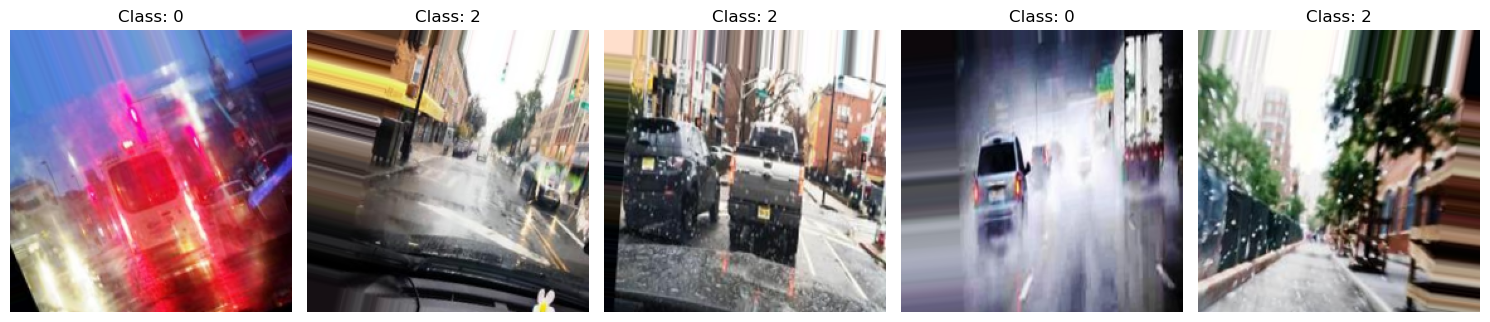

{'heavy': 0, 'light': 1, 'medium': 2}

In [15]:
# Plot the augmented images
import numpy as np
plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_batch[i])
    plt.title(f"Class: {np.argmax(y_batch[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Also show type of augmentation applied
sample_plot_data.class_indices

Validation Datagen

In [16]:
valid_datagen = ImageDataGenerator(
    rescale=1.0/255.0  
)

In [17]:
# Load the training and validation data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 748 images belonging to 3 classes.


In [18]:
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 195 images belonging to 3 classes.


In [19]:
# Get the number of classes
num_classes = len(train_generator.class_indices)
print(f"Num Classes: {num_classes}")

Num Classes: 3


## **Model Building**

### **CNN Model**

In [20]:
# Define the CNN model
model_01 = Sequential([
    # Convolutional layers
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Fully connected layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  
    Dense(num_classes, activation='softmax')
])

c:\Users\91790\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# Compile the model
model_01.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
# Print the model summary
model_01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Train the model
history_01 = model_01.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/15


c:\Users\91790\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.3728 - loss: 1.8210 - val_accuracy: 0.3229 - val_loss: 1.0970
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2812 - loss: 1.1049 - val_accuracy: 0.3333 - val_loss: 1.1052
Epoch 3/15


c:\Users\91790\anaconda3\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.4019 - loss: 1.0915 - val_accuracy: 0.4167 - val_loss: 1.0777
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2812 - loss: 1.1200 - val_accuracy: 0.6667 - val_loss: 1.0332
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.3753 - loss: 1.0938 - val_accuracy: 0.4583 - val_loss: 1.0637
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3750 - loss: 1.0997 - val_accuracy: 0.3333 - val_loss: 0.9593
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.3905 - loss: 1.0900 - val_accuracy: 0.5104 - val_loss: 1.0442
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6562 - loss: 0.9172 - val_accuracy: 0.3333 - val_loss: 1.7625
Epoch 9/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.4021 - loss: 1.0924 - val_accuracy: 0.4948 - val_loss: 1.0091
Epoch 10/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4688 - loss: 1.0833 - val_accuracy: 0.6667 - val_loss: 1.0107
Ep

In [24]:
# Save the trained model
model_01.save("models_trained/cnn_model.h5")
print("Model saved as cnn_model.h5")

Model saved as cnn_model.h5


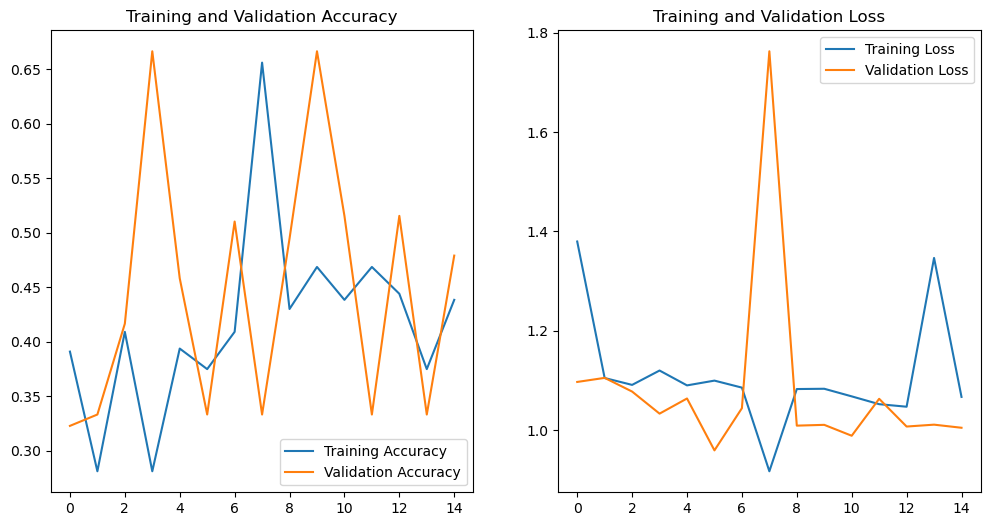

In [25]:
# Plot training and validation performance
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(EPOCHS)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_training_history(history_01)

In [26]:
# get acc
get_accuracy(history_01)

Best Training Accuracy: 0.65625
Best Validation Accuracy: 0.6666666865348816


### **ResNet50**

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

In [28]:
# Load the ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

In [29]:
# Freeze the base model layers
base_model.trainable = False

In [30]:
# Add custom classification layers
resnet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(), 

    # First dense layer
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Second dense layer
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Third dense layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(num_classes, activation='softmax')  
])

# Compile the model
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
# Train the model
result = resnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.3810 - loss: 1.8751 - val_accuracy: 0.3229 - val_loss: 1.4195
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4062 - loss: 2.4468 - val_accuracy: 0.3333 - val_loss: 0.8184
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3280 - loss: 1.7545 - val_accuracy: 0.3229 - val_loss: 1.2653
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4062 - loss: 1.4554 - val_accuracy: 0.3333 - val_loss: 1.4062
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3659 - loss: 1.6383 - val_accuracy: 0.3281 - val_loss: 1.2783
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4375 - loss: 1.6608 - val_accuracy: 0.0000e+00 - val_loss: 1.0198
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3735 - loss: 1.5593 - val_accuracy: 0.3281 - val_loss: 1.1251
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5000 - loss: 1.2426 - val_accuracy: 0.3333 - v

In [32]:
resnet_model.save("models_trained/resnet50_model.h5")
print("Model saved as resnet50_model.h5")

Model saved as resnet50_model.h5


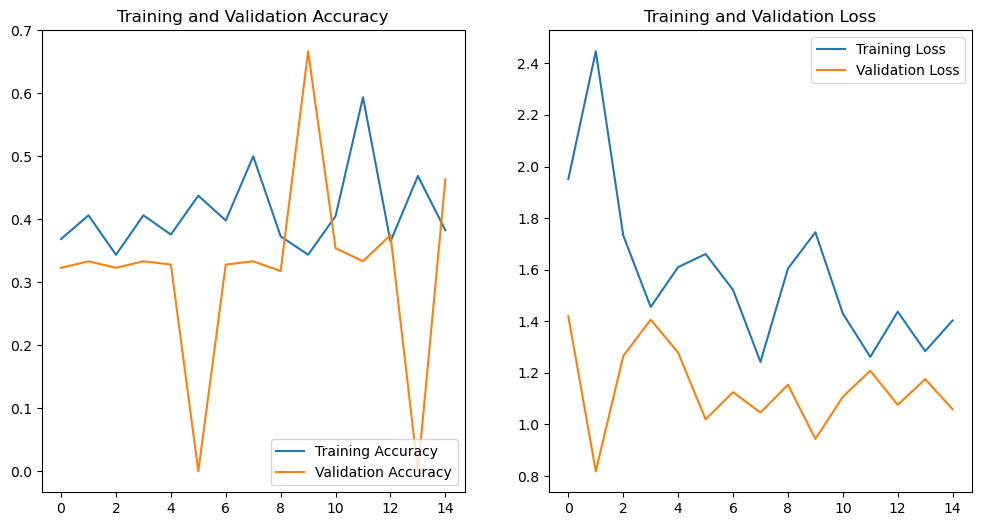

In [33]:
plot_training_history(result)

In [34]:
# get acc
get_accuracy(result)

Best Training Accuracy: 0.59375
Best Validation Accuracy: 0.6666666865348816


### **Xception Model**

In [8]:
# Load the Xception model
from tensorflow.keras.applications import Xception
xception_base = Xception(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

NameError: name 'IMG_HEIGHT' is not defined

In [36]:
# Freeze the base model layers
xception_base.trainable = False

In [37]:
# Add custom classification layers
xception_model = Sequential([
    xception_base,
    GlobalAveragePooling2D(),  

    # First dense layer
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Second dense layer
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(num_classes, activation='softmax')
])

In [ ]:
# Compile the model
xception_model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
# Train the model
result_1 = xception_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.4038 - loss: 1.9215 - val_accuracy: 0.6562 - val_loss: 0.8203
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.5938 - loss: 1.3146 - val_accuracy: 0.3333 - val_loss: 0.8662
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.5070 - loss: 1.3533 - val_accuracy: 0.5469 - val_loss: 0.8800
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4688 - loss: 1.3520 - val_accuracy: 0.6667 - val_loss: 0.8623
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 107s 4s/step - accuracy: 0.5524 - loss: 1.2145 - val_accuracy: 0.6562 - val_loss: 0.7671
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7500 - loss: 0.5641 - val_accuracy: 0.6667 - val_loss: 0.8764
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - accuracy: 0.6213 - loss: 1.0365 - val_accuracy: 0.6979 - val_loss: 0.6667
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5625 - loss: 1.1818 - val_accuracy: 0.3333 - va

In [40]:
xception_model.save("models_trained/xception_model.h5")
print("Model saved as xception_model.h5")

Model saved as xception_model.h5


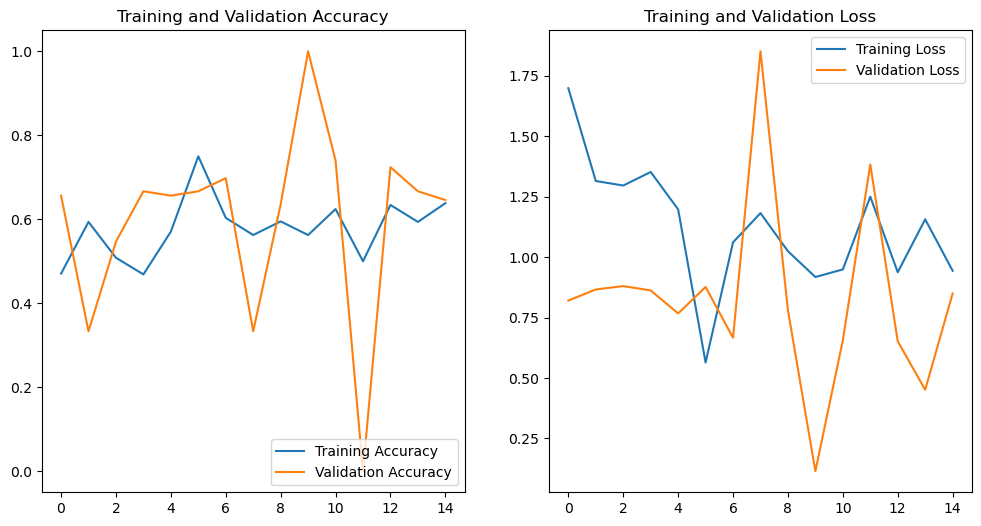

In [41]:
plot_training_history(result_1)

In [42]:
# Get best accuracy
get_accuracy(result_1)

Best Training Accuracy: 0.75
Best Validation Accuracy: 1.0


After multiple experiments, **Xception model proves out to be the best** among all three approach with an **training accuracy of 75%** and **validation accuracy of 95%+**!

### **Evaluation : Let's Test our models**

In [ ]:
test_datagen = ImageDataGenerator(  
    rescale=1.0/255.0   
)
test_gen = test_datagen.flow_from_directory(
    directory="resized_dataset/valid/",
    target_size=(224, 224),
    batch_size=8, 
    class_mode="categorical", 
    shuffle=False
)

Found 195 images belonging to 3 classes.


In [44]:
evaluation = model_01.evaluate(test_gen)
print(f"Test Loss: {evaluation[0]}")
print(f"Test Accuracy: {evaluation[1]}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6391 - loss: 0.9679
Test Loss: 1.0054187774658203
Test Accuracy: 0.482051283121109


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns 

In [46]:
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

In [47]:
# Get predictions 
def get_predictions(model):
    evaluation = model.evaluate(test_gen)
    print(f"Test Loss: {evaluation[0]}")
    print(f"Test Accuracy: {evaluation[1]}")
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen), axis=1)

    # Generate the classification report
    # Classification Report 
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6391 - loss: 0.9679
Test Loss: 1.0054187774658203
Test Accuracy: 0.482051283121109
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step


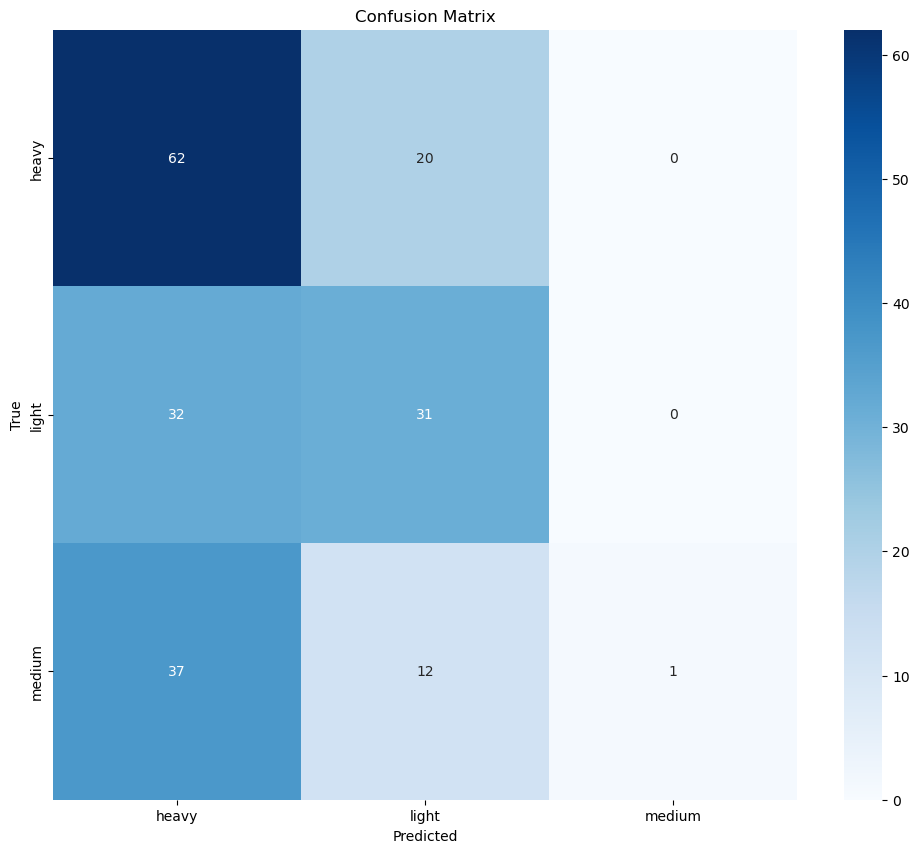

In [48]:
# Get Predictions for CNN model 
get_predictions(model_01)

In [49]:
# Visualize some predictions to understand model behavior 
x_test_batch, y_test_batch = next(test_gen)

def visualize_predictions(model): 
    predictions = model.predict(x_test_batch)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(y_test_batch, axis=1)

    # Display images with predictions 
    plt.figure(figsize=(20, 16))
    for i in range(min(20, len(x_test_batch))):
        plt.subplot(4, 5, i+1)
        plt.imshow(x_test_batch[i])
        plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}")
        if true_classes[i] == predicted_classes[i]:
            plt.xlabel('CORRECT', color='green')
        else:
            plt.xlabel('WRONG', color='red')
        plt.tight_layout()
        plt.axis('off')
    plt.show()

Visualize Some Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


C:\Users\91790\AppData\Local\Temp\ipykernel_19096\2676401062.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


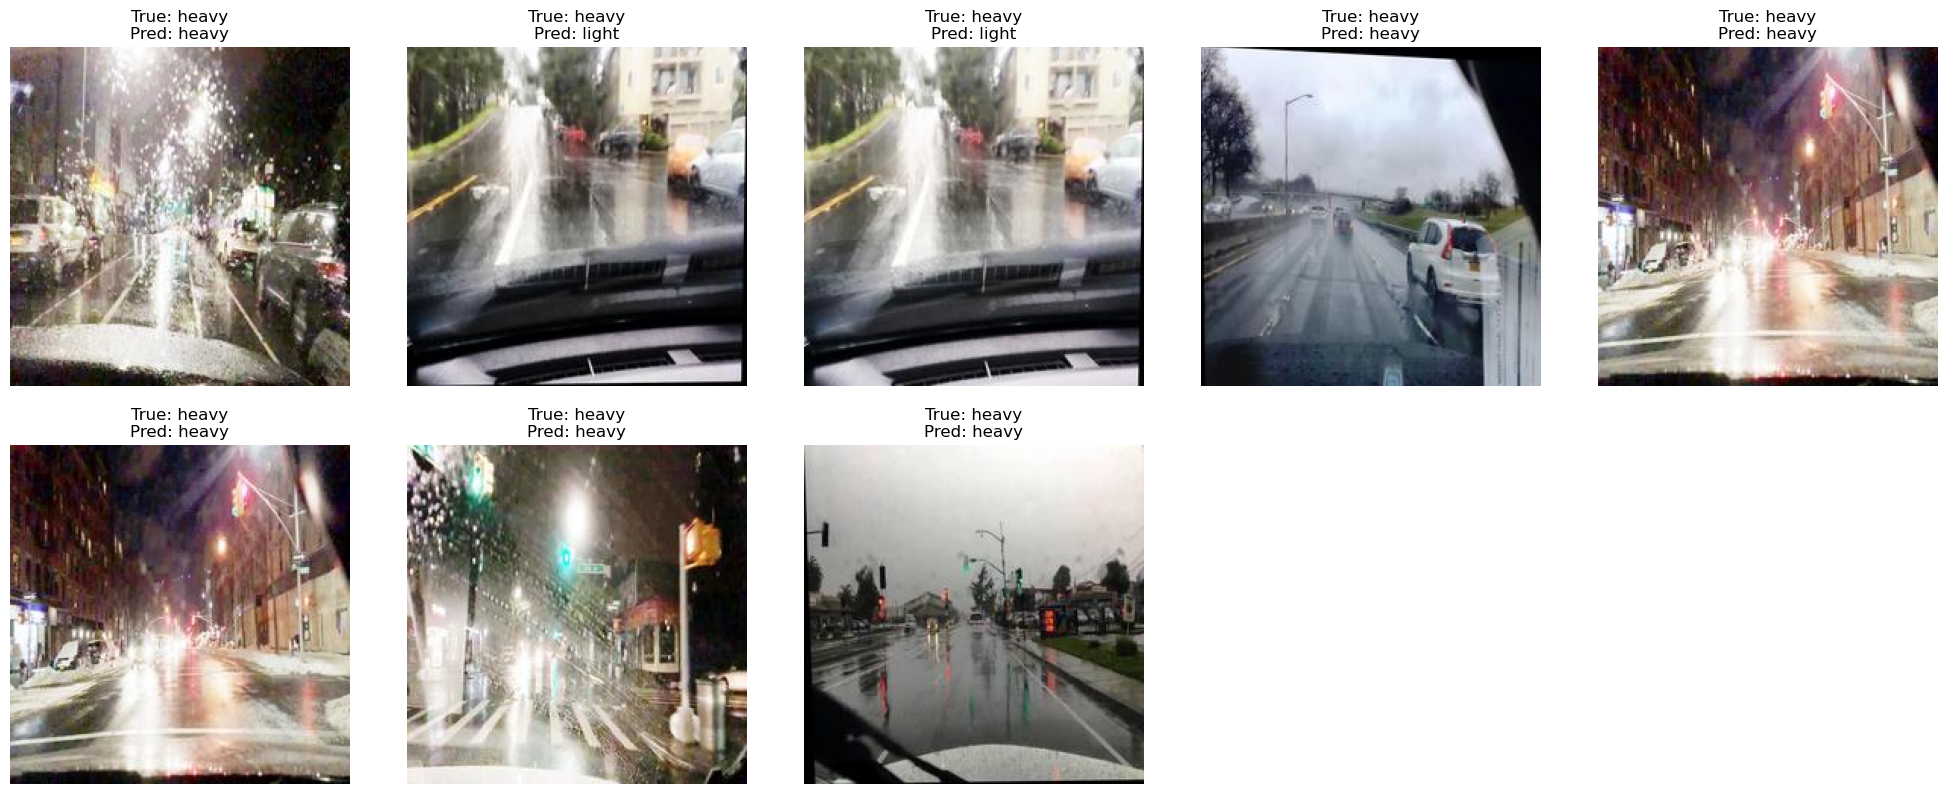

In [50]:
# Get prediction visualizations for CNN model 
visualize_predictions(model_01)

### **Compress and Load model for test**

Compress:

In [6]:
"""Uncomment and run to compress and save"""

# import tensorflow as tf
# model = tf.keras.models.load_model("models_trained/xception_model.h5")

# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]

# tflite_model = converter.convert()

# with open("models_trained/xception_quant.tflite", "wb") as f:
#     f.write(tflite_model)

'Uncomment and run to compress and save'

Test:

In [5]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
interpreter = tf.lite.Interpreter(model_path="models_trained/xception_quant.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_gen = test_datagen.flow_from_directory(
    "resized_dataset/valid",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(test_gen.class_indices.keys())

Found 195 images belonging to 3 classes.


In [11]:
correct = 0
total = 0

y_true = []
y_pred = []

for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]

    for j in range(len(x_batch)):
        img = x_batch[j].astype(np.float32)
        img = np.expand_dims(img, axis=0)

        interpreter.set_tensor(input_details[0]['index'], img)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details[0]['index'])

        pred = np.argmax(output)
        true = np.argmax(y_batch[j])

        y_pred.append(pred)
        y_true.append(true)

        if pred == true:
            correct += 1
        total += 1


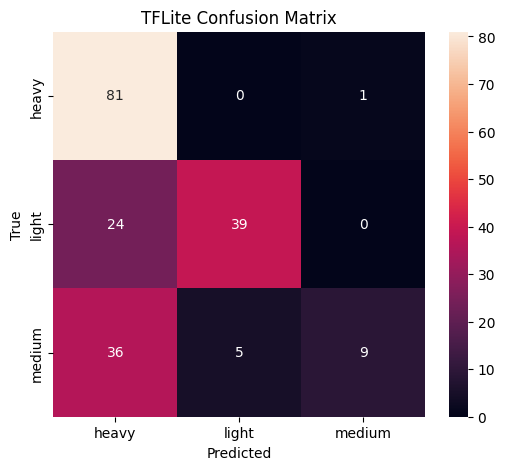

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("TFLite Confusion Matrix")
plt.show()